# Jawad Hassan
# 2230-0035
# BS AI
# ANN
# Lab 07


### Task 1:
### Run class example of EMNIST dataset classification Add code portion and also its prediction output.

In [8]:
import tensorflow_datasets as tfds
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("Downloading EMNIST via TensorFlow Datasets...")

# FIX: Added with_info=True so the variables unpack correctly
dataset, info = tfds.load('emnist/balanced', split=['train', 'test'], batch_size=-1, as_supervised=True, with_info=True)

ds_train, ds_test = dataset

# Extract the tensors
X_train_tensor, y_train_tensor = ds_train
X_test_tensor, y_test_tensor = ds_test

# Convert the TensorFlow tensors to standard NumPy arrays
X_train = X_train_tensor.numpy()
y_train = y_train_tensor.numpy()
X_test = X_test_tensor.numpy()
y_test = y_test_tensor.numpy()

# EMNIST images are famously rotated 90 degrees and flipped by default.
# This line fixes the rotation so they look normal to human eyes.(Batch_Size, Height, Width, Color_Channels)
X_train = np.transpose(X_train, (0, 2, 1, 3))
X_test = np.transpose(X_test, (0, 2, 1, 3))

# Normalize pixel values (0 to 1) and ensure they are floats
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (112800, 28, 28, 1)
Test data shape: (18800, 28, 28, 1)


In [9]:
print("Building the CNN model...")

# Build the CNN model
model = tf.keras.Sequential([
    # Convolutional layer: The 'eyes' of the network looking for visual features
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(2, 2), # Shrinks the image map to compute faster

    # Flatten layer: Converts the 2D image data into a 1D array for the Dense layers
    tf.keras.layers.Flatten(),

    # Standard ANN Dense layers
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(47, activation='softmax') # 47 output classes for the 'balanced' dataset
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
print("Starting training...")
history = model.fit(X_train, y_train, epochs=5, validation_split=0.1)

Building the CNN model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting training...
Epoch 1/5
3173/3173 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.7675 - loss: 0.7548 - val_accuracy: 0.8290 - val_loss: 0.5104
Epoch 2/5
3173/3173 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8482 - loss: 0.4506 - val_accuracy: 0.8459 - val_loss: 0.4483
Epoch 3/5
3173/3173 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8661 - loss: 0.3849 - val_accuracy: 0.8539 - val_loss: 0.4279
Epoch 4/5
3173/3173 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8787 - loss: 0.3397 - val_accuracy: 0.8550 - val_loss: 0.4185
Epoch 5/5
3173/3173 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8887 - loss: 0.3016 - val_accuracy: 0.8534 - val_loss: 0.4280


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step


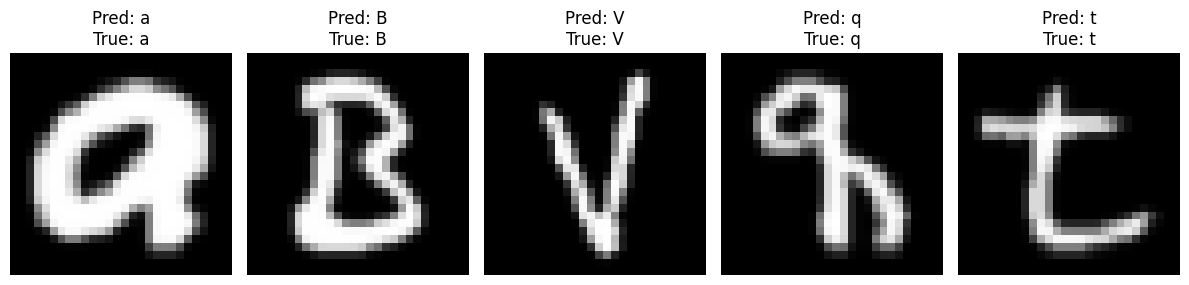

In [10]:
# Make predictions on the first 5 images of the test set
predictions = model.predict(X_test[:5])

# EMNIST 'balanced' mapping characters
emnist_mapping = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabdefghnqrt"

# Display the image alongside its prediction
plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    # Reshape back to 28x28 for plotting
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')

    # Get the index of the highest probability
    predicted_class = np.argmax(predictions[i])
    actual_class = y_test[i]

    # Map the index to the actual character
    pred_char = emnist_mapping[predicted_class]
    actual_char = emnist_mapping[actual_class]

    plt.title(f"Pred: {pred_char}\nTrue: {actual_char}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Task 2:
### Use the given dataset of fruits. Use CNN classification algorithm to classify images. Add code portion and also its prediction output.
### link: https://www.kaggle.com/datasets/karimabdulnabi/fruit-classification10-class?select=MY_data

In [1]:
import os
from google.colab import files

print("Please upload your kaggle.json file:")
files.upload() # This will open an upload button

# Move the kaggle.json file to the hidden folder where the API expects it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Downloading dataset from Kaggle...")
# Download the specific dataset using its Kaggle API command
!kaggle datasets download -d karimabdulnabi/fruit-classification10-class

print("Unzipping data...")
# Unzip the downloaded file quietly (-q) into a folder named 'fruit_data'
!unzip -q fruit-classification10-class.zip -d fruit_data

print("Dataset successfully loaded into Colab!")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/karimabdulnabi/fruit-classification10-class
License(s): CC0-1.0
100% 29.2M/29.2M [00:00<00:00, 117MB/s] 

Unzipping data...
Dataset successfully loaded into Colab!


In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Load the Data
# Note: You may need to check the exact folder structure inside 'fruit_data' using the folder icon on the left of Colab.
# Assuming the images are in a 'train' and 'test' folder inside 'fruit_data'
data_dir = 'fruit_data/MY_data/train' # Update this path if the unzipped folder structure is slightly different

# Load training data and resize all images to 128x128 pixels
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(128, 128),
  batch_size=32)

# Load validation data
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(128, 128),
  batch_size=32)

# Extract the class names (the names of the 10 fruits)
class_names = train_ds.class_names
print(f"Classes found: {class_names}")

# 2. Build the CNN
print("Building the CNN model...")
model = tf.keras.Sequential([
    # Rescaling layer: Normalizes the pixel values from 0-255 to 0-1 (just like we did manually for EMNIST)
    tf.keras.layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    # Convolutional Layers (The 'eyes')
    # We use a few more layers here because color images of fruit are more complex than black and white letters
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Flatten and Dense Layers (The 'brain')
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
     # NEW: Drops 50% of connections randomly to prevent memorization
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax') # 10 output classes for the 10 fruits
])

# 3. Compile and Train
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Setting up Early Stopping...")
# Define the Early Stopping rules
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',         # The metric we want to watch for overfitting
    patience=3,                 # How many epochs to wait after the val_loss stops improving
    restore_best_weights=True   # CRUCIAL: Rolls the model back to its smartest state
)

print("Starting training...")
# Pass the early_stopping rule into the 'callbacks' list
# I left your epochs at 15, but it will likely stop itself well before it hits 15!
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping]  # <--- This is where it gets applied
)

Found 2301 files belonging to 10 classes.
Using 1841 files for training.
Found 2301 files belonging to 10 classes.
Using 460 files for validation.
Classes found: ['Apple', 'Banana', 'avocado', 'cherry', 'kiwi', 'mango', 'orange', 'pinenapple', 'strawberries', 'watermelon']
Building the CNN model...
Setting up Early Stopping...
Starting training...
Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - accuracy: 0.1754 - loss: 2.1804 - val_accuracy: 0.2826 - val_loss: 1.9257
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3265 - loss: 1.8303 - val_accuracy: 0.3804 - val_loss: 1.6193
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3857 - loss: 1.6268 - val_accuracy: 0.4587 - val_loss: 1.4015
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4557 - loss: 1.4661 - val_accuracy: 0.5087 - val_loss: 1.3130
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.5204 - loss: 1.3341 - val_accuracy: 0.5196 - val_loss: 1.2814
Epoch 6/15
58/

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


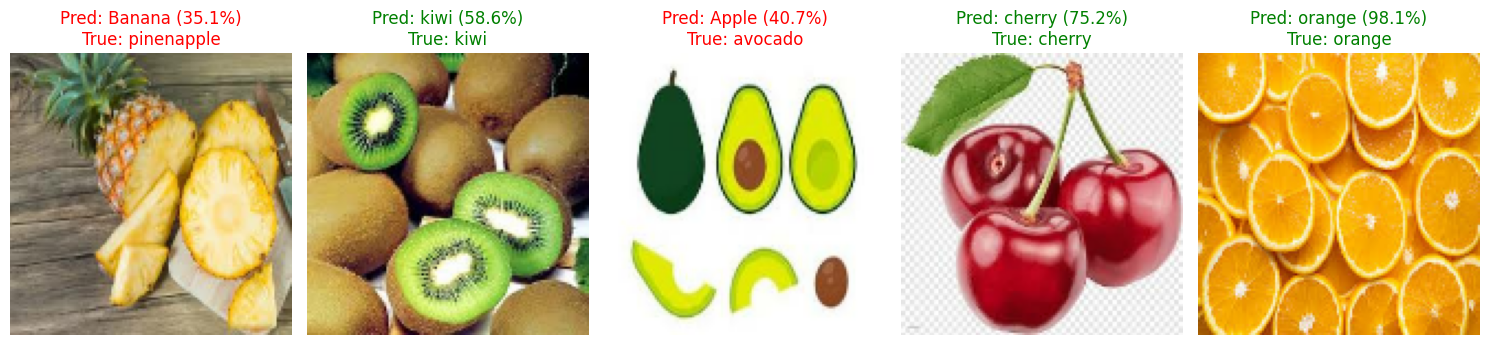

In [10]:
# Grab a random batch of images rather than the very first one
for images, labels in val_ds.shuffle(100).take(1):
    predictions = model.predict(images)

    plt.figure(figsize=(15, 6))
    for i in range(5):
        plt.subplot(1, 5, i + 1)

        # Convert the tensor to a standard image format for plotting
        img = images[i].numpy().astype("uint8")
        plt.imshow(img)

        # Get the predicted and actual class names (.numpy() ensures clean mapping)
        predicted_class = class_names[np.argmax(predictions[i])]
        actual_class = class_names[labels[i].numpy()]

        # Calculate how confident the model is in its guess
        confidence = np.max(predictions[i]) * 100

        # Color the title green if correct, red if wrong
        color = 'green' if predicted_class == actual_class else 'red'

        plt.title(f"Pred: {predicted_class} ({confidence:.1f}%)\nTrue: {actual_class}", color=color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
    break